In [2]:
# @title Default title text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

df = pd.read_csv(
    "4) house Prediction Data Set.csv",
    sep=r"\s+",
    header=None,
    names=columns
)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [17]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [19]:
df.duplicated().sum()

np.int64(0)

In [22]:
df = df.drop_duplicates()

In [25]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

In [27]:
# Confirm final cleaned dataset shape
df.shape

(506, 14)

In [29]:
# Save cleaned dataset
df.to_csv("cleaned_house_prediction_data.csv", index=False)

# Level 1 - Task 2: Exploratory Data Analysis

In this section, I performed exploratory data analysis on the cleaned House Prediction Dataset. The analysis includes summary statistics, data distributions, boxplots, scatter plots, and correlation analysis.

In [31]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [33]:
df.shape

(506, 14)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [35]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [36]:
summary_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Standard Deviation": df.std()
})

summary_stats

,Mean,Median,Mode,Standard Deviation
CRIM,3.613524,0.25651,0.01501,8.601545
ZN,11.363636,0.00000,0.00000,23.322453
INDUS,11.136779,9.69000,18.10000,6.860353
CHAS,0.069170,0.00000,0.00000,0.253994
NOX,0.554695,0.53800,0.53800,0.115878
RM,6.284634,6.20850,5.71300,0.702617
AGE,68.574901,77.50000,100.00000,28.148861
DIS,3.795043,3.20745,3.49520,2.105710
RAD,9.549407,5.00000,24.00000,8.707259
TAX,408.237154,330.00000,666.00000,168.537116


The summary statistics show the central tendency and spread of each numerical feature. The dataset contains numerical housing-related variables such as crime rate, number of rooms, tax rate, pupil-teacher ratio, and house value.

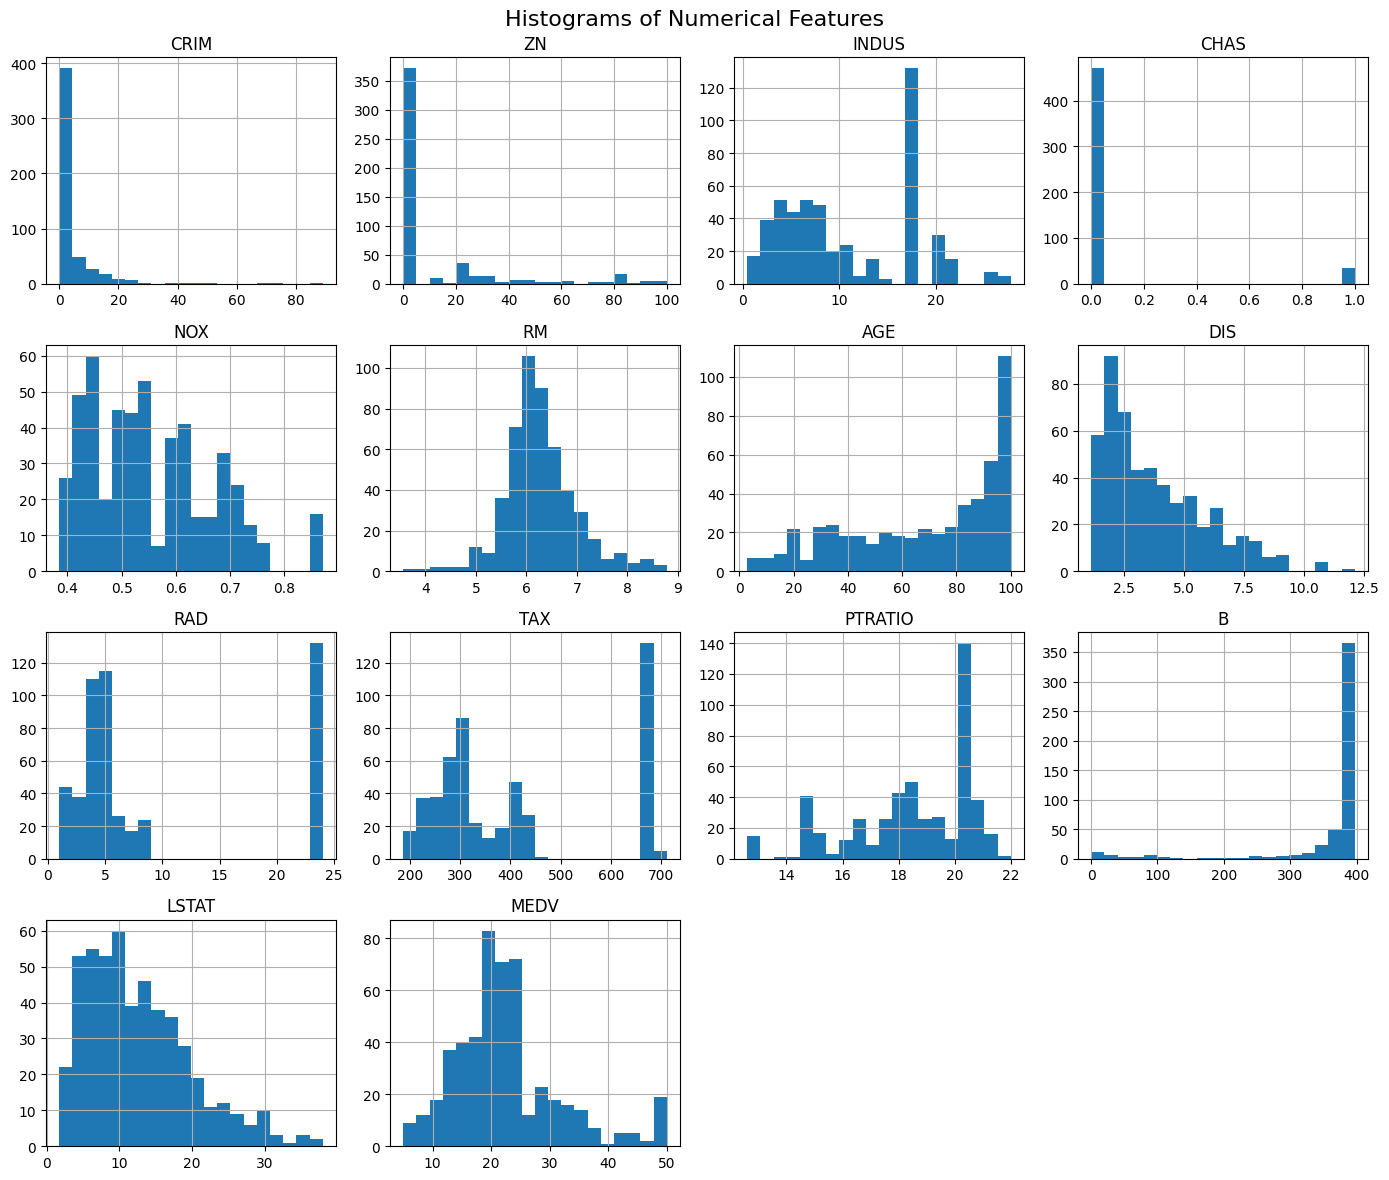

In [37]:
df.hist(figsize=(14, 12), bins=20)

plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout()
plt.savefig("histograms_numerical_features.png", dpi=300, bbox_inches="tight")
plt.show()

The histograms show the distribution of numerical features. Some variables appear normally distributed, while others are skewed, indicating that the dataset contains unevenly distributed values.

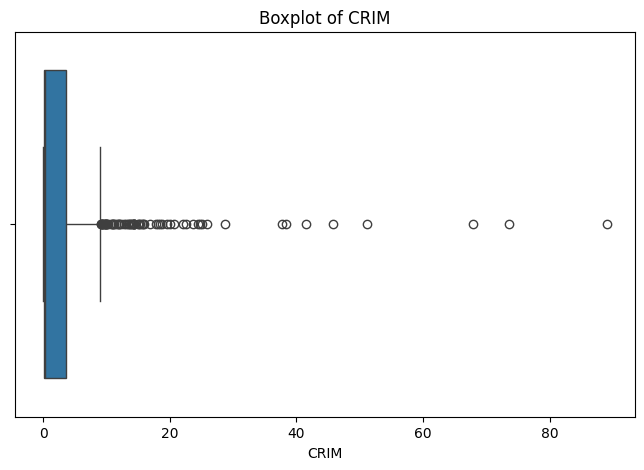

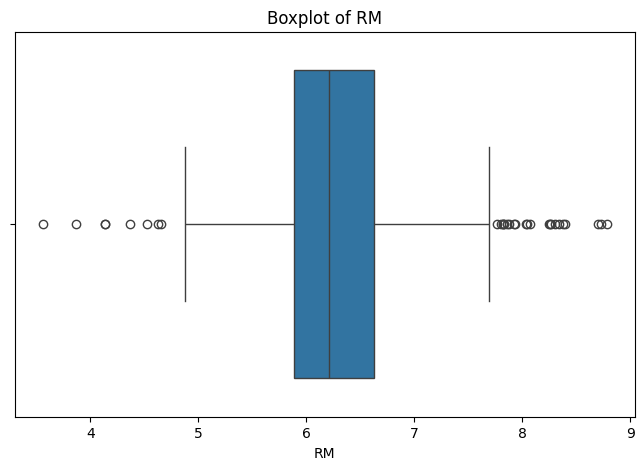

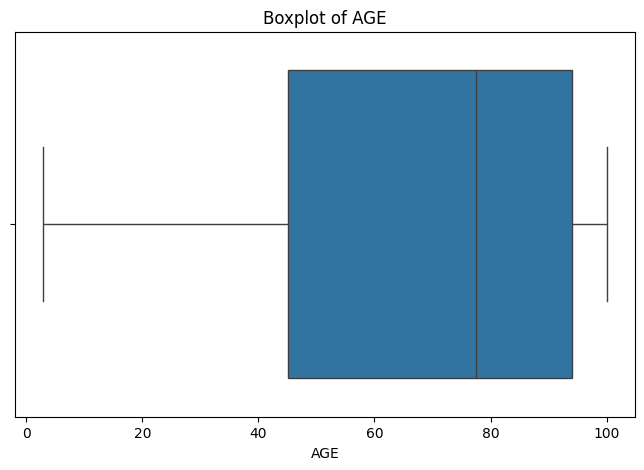

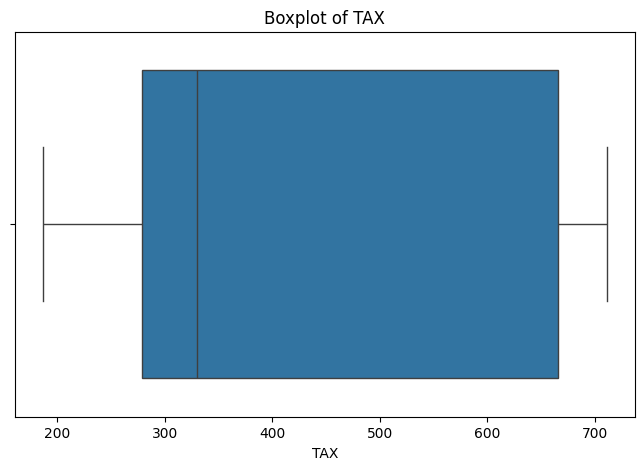

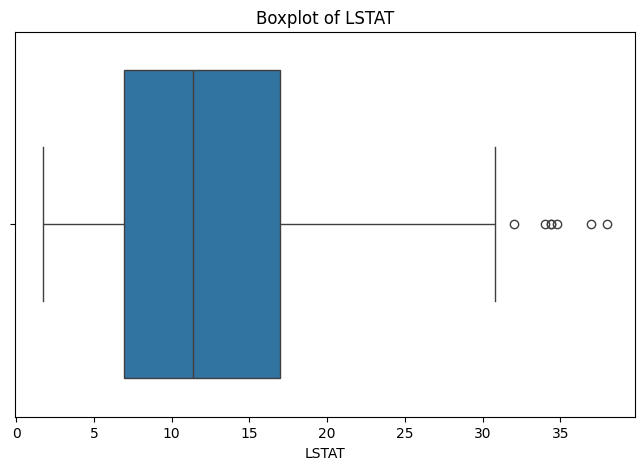

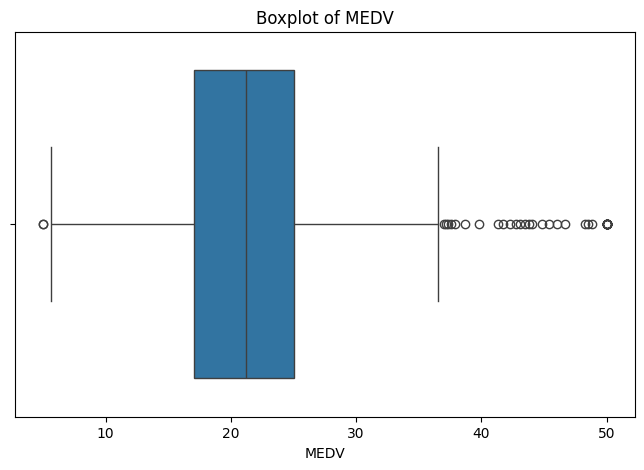

In [38]:
selected_columns = ["CRIM", "RM", "AGE", "TAX", "LSTAT", "MEDV"]

for col in selected_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.savefig(f"boxplot_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

The boxplots help identify possible outliers in the dataset. Features such as CRIM and MEDV show visible outliers, which means some observations are much higher or lower than the majority of the data.

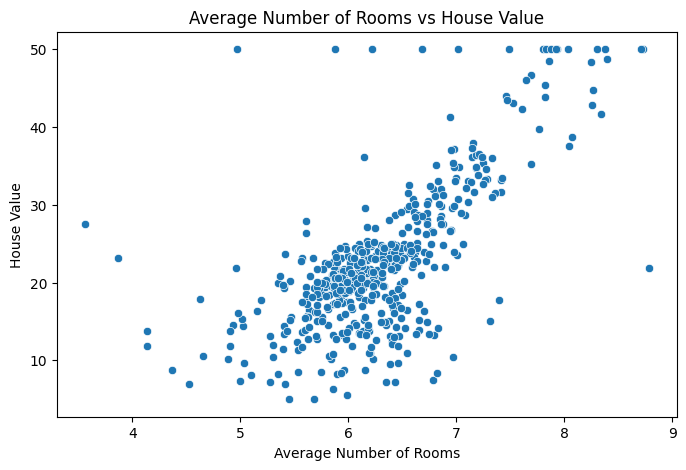

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="RM", y="MEDV")
plt.title("Average Number of Rooms vs House Value")
plt.xlabel("Average Number of Rooms")
plt.ylabel("House Value")
plt.savefig("scatter_rm_vs_medv.png", dpi=300, bbox_inches="tight")
plt.show()

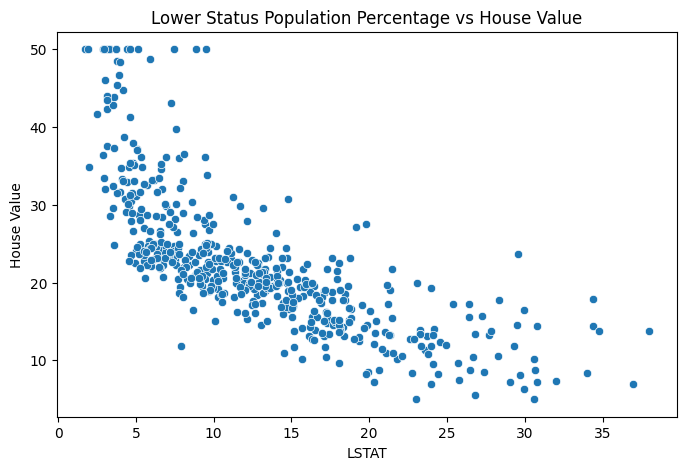

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="LSTAT", y="MEDV")
plt.title("Lower Status Population Percentage vs House Value")
plt.xlabel("LSTAT")
plt.ylabel("House Value")
plt.savefig("scatter_lstat_vs_medv.png", dpi=300, bbox_inches="tight")
plt.show()

The scatter plot between RM and MEDV shows that houses with more rooms generally have higher values. The scatter plot between LSTAT and MEDV shows a negative relationship, meaning that as LSTAT increases, house value tends to decrease.

In [41]:
correlation_matrix = df.corr()

correlation_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


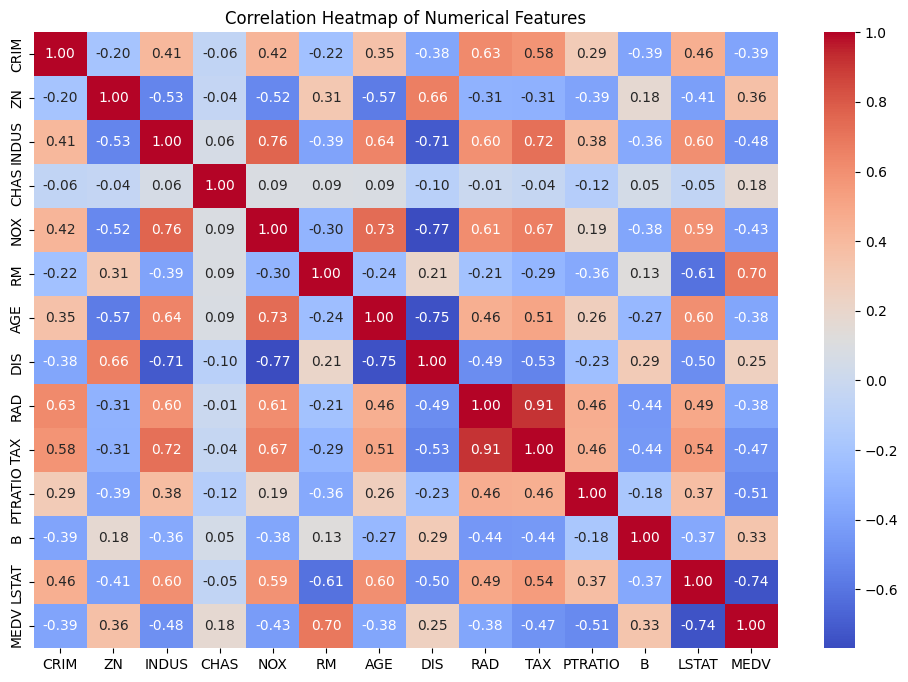

In [42]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation heatmap shows relationships between numerical features. RM has a positive correlation with MEDV, meaning house value tends to increase as the average number of rooms increases. LSTAT has a negative correlation with MEDV, meaning house value tends to decrease as LSTAT increases.

In [43]:
medv_correlation = df.corr()["MEDV"].sort_values(ascending=False)

medv_correlation

,MEDV
MEDV,1.000000
RM,0.695360
ZN,0.360445
B,0.333461
DIS,0.249929
CHAS,0.175260
AGE,-0.376955
RAD,-0.381626
CRIM,-0.388305
NOX,-0.427321


The strongest positive relationship with house value is RM. The strongest negative relationship with house value is LSTAT. This means the number of rooms and lower-status population percentage are important variables when analyzing house values.

## Task 2 Conclusion

In this exploratory data analysis, I calculated summary statistics including mean, median, mode, and standard deviation for the numerical features in the House Prediction Dataset.

I also visualized the data using histograms, boxplots, scatter plots, and a correlation heatmap. The histograms helped show feature distributions, while the boxplots helped identify possible outliers.

The scatter plots showed that RM has a positive relationship with MEDV, meaning house values tend to increase as the average number of rooms increases. LSTAT has a negative relationship with MEDV, meaning house values tend to decrease as LSTAT increases.

The correlation analysis confirmed that RM has one of the strongest positive correlations with MEDV, while LSTAT has one of the strongest negative correlations with MEDV.

In [44]:
import zipfile
import os
from google.colab import files

# Files to include in the ZIP
files_to_zip = [
    "cleaned_house_prediction_data.csv",
    "histograms_numerical_features.png",
    "boxplot_CRIM.png",
    "boxplot_RM.png",
    "boxplot_AGE.png",
    "boxplot_TAX.png",
    "boxplot_LSTAT.png",
    "boxplot_MEDV.png",
    "scatter_rm_vs_medv.png",
    "scatter_lstat_vs_medv.png",
    "correlation_heatmap.png"
]

zip_filename = "level_1_task_1_and_2_outputs.zip"

with zipfile.ZipFile(zip_filename, "w") as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"Added: {file}")
        else:
            print(f"Missing: {file}")

files.download(zip_filename)

Added: cleaned_house_prediction_data.csv
Added: histograms_numerical_features.png
Added: boxplot_CRIM.png
Added: boxplot_RM.png
Added: boxplot_AGE.png
Added: boxplot_TAX.png
Added: boxplot_LSTAT.png
Added: boxplot_MEDV.png
Added: scatter_rm_vs_medv.png
Added: scatter_lstat_vs_medv.png
Added: correlation_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading the files